In [278]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

In [279]:
CASE_INDEX = 2

In [280]:
PROJECT_ROOT = Path.cwd().parent.parent.parent

EXTRACTED_DIR = (
        PROJECT_ROOT
        / "data"
        / "extracted"
        / "merged_cells"
)

MANIFEST_PATH = EXTRACTED_DIR / "manifest.csv"

ROLE_NAMES = (
    "cell_1",
    "cell_2",
    "merged_cell",
)

REQUIRED_ARTIFACTS = (
    "raw",
    "preprocessed",
    "binary_mask",
    "instance_labels",
    "selected_cell_mask",
)

print("Project root:")
print(PROJECT_ROOT)

print("\nExtracted cases:")
print(EXTRACTED_DIR)

print("\nManifest:")
print(MANIFEST_PATH)

Project root:
D:\Projects\Kaggle\cell-tracking

Extracted cases:
D:\Projects\Kaggle\cell-tracking\data\extracted\merged_cells

Manifest:
D:\Projects\Kaggle\cell-tracking\data\extracted\merged_cells\manifest.csv


In [281]:
def discover_merged_cell_cases(
        extracted_dir: Path,
        manifest_path: Path,
) -> pd.DataFrame:
    if not manifest_path.exists():
        raise FileNotFoundError(
            f"Merged-cell manifest was not found:\n{manifest_path}"
        )

    cases = pd.read_csv(manifest_path)

    required_columns = {
        "case_name",
        "sample_id",
        "cell_1_frame",
        "cell_1_id",
        "cell_2_frame",
        "cell_2_id",
        "merged_frame",
        "merged_cell_id",
    }

    missing_columns = required_columns.difference(cases.columns)

    if missing_columns:
        raise KeyError(
            "The merged-cell manifest is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    cases = cases.copy()

    cases["case_dir"] = cases["case_name"].map(
        lambda name: extracted_dir / str(name)
    )

    cases["case_exists"] = cases["case_dir"].map(Path.exists)

    for role in ROLE_NAMES:
        cases[f"has_{role}"] = cases["case_dir"].map(
            lambda path, role=role: (path / role).is_dir()
        )

    return cases.sort_values(
        [
            "sample_id",
            "merged_frame",
            "merged_cell_id",
        ]
    ).reset_index(drop=True)


cases = discover_merged_cell_cases(
    extracted_dir=EXTRACTED_DIR,
    manifest_path=MANIFEST_PATH,
)

cases[
    [
        "case_name",
        "sample_id",
        "cell_1_frame",
        "cell_1_id",
        "cell_2_frame",
        "cell_2_id",
        "merged_frame",
        "merged_cell_id",
        "has_cell_1",
        "has_cell_2",
        "has_merged_cell",
    ]
]

,case_name,sample_id,cell_1_frame,cell_1_id,cell_2_frame,cell_2_id,merged_frame,merged_cell_id,has_cell_1,has_cell_2,has_merged_cell
0,44b6_0113de3b__cell1_t006_id00118__cell2_t006_...,44b6_0113de3b,6,118,6,129,8,130,True,True,True
1,44b6_0113de3b__cell1_t009_id00063__cell2_t009_...,44b6_0113de3b,9,63,9,74,10,79,True,True,True
2,44b6_0113de3b__cell1_t010_id00071__cell2_t010_...,44b6_0113de3b,10,71,10,82,11,71,True,True,True
3,44b6_0113de3b__cell1_t009_id00063__cell2_t009_...,44b6_0113de3b,9,63,9,74,12,86,True,True,True
4,44b6_0113de3b__cell1_t015_id00042__cell2_t015_...,44b6_0113de3b,15,42,15,68,17,42,True,True,True


In [282]:
if not 0 <= CASE_INDEX < len(cases):
    raise IndexError(
        f"CASE_INDEX must be between 0 and {len(cases) - 1}; "
        f"received {CASE_INDEX}."
    )

selected_case = cases.iloc[CASE_INDEX]

CASE_NAME = str(selected_case["case_name"])
CASE_DIR = Path(selected_case["case_dir"])

print("Selected case:")
print(CASE_NAME)

print("\nCase directory:")
print(CASE_DIR)

print(
    "\nParent 1:",
    f"frame={int(selected_case['cell_1_frame'])},",
    f"cell_id={int(selected_case['cell_1_id'])}",
)

print(
    "Parent 2:",
    f"frame={int(selected_case['cell_2_frame'])},",
    f"cell_id={int(selected_case['cell_2_id'])}",
)

print(
    "Merged cell:",
    f"frame={int(selected_case['merged_frame'])},",
    f"cell_id={int(selected_case['merged_cell_id'])}",
)

Selected case:
44b6_0113de3b__cell1_t010_id00071__cell2_t010_id00082__merged_t011_id00071

Case directory:
D:\Projects\Kaggle\cell-tracking\data\extracted\merged_cells\44b6_0113de3b__cell1_t010_id00071__cell2_t010_id00082__merged_t011_id00071

Parent 1: frame=10, cell_id=71
Parent 2: frame=10, cell_id=82
Merged cell: frame=11, cell_id=71


In [283]:
def load_role(
        case_dir: Path,
        role: str,
) -> dict[str, Any]:
    if role not in ROLE_NAMES:
        raise ValueError(
            f"Unknown role {role!r}. Expected one of {ROLE_NAMES}."
        )

    role_dir = case_dir / role
    metadata_path = role_dir / "metadata.json"
    features_path = role_dir / "features.csv"

    if not role_dir.is_dir():
        raise FileNotFoundError(
            f"Role directory was not found:\n{role_dir}"
        )

    if not metadata_path.exists():
        raise FileNotFoundError(
            f"Role metadata was not found:\n{metadata_path}"
        )

    with metadata_path.open("r", encoding="utf-8") as file:
        metadata = json.load(file)

    artifact_files = metadata.get("artifact_files", {})

    arrays: dict[str, np.ndarray] = {}
    artifact_paths: dict[str, Path] = {}

    for artifact_name in REQUIRED_ARTIFACTS:
        filename = artifact_files.get(
            artifact_name,
            f"{artifact_name}.npy",
        )

        artifact_path = role_dir / filename

        if not artifact_path.exists():
            raise FileNotFoundError(
                f"Required artifact {artifact_name!r} is missing "
                f"for role {role!r}:\n{artifact_path}"
            )

        arrays[artifact_name] = np.load(
            artifact_path,
            allow_pickle=False,
        )

        artifact_paths[artifact_name] = artifact_path

    features = None

    if features_path.exists():
        features = pd.read_csv(features_path)

    shapes = {
        name: array.shape
        for name, array in arrays.items()
    }

    if len(set(shapes.values())) != 1:
        raise ValueError(
            f"Artifacts for role {role!r} are not voxel-aligned: "
            f"{shapes}"
        )

    selected_mask = arrays["selected_cell_mask"].astype(bool)

    if not selected_mask.any():
        raise ValueError(
            f"The selected-cell mask for role {role!r} is empty."
        )

    return {
        "role": role,
        "directory": role_dir,
        "metadata_path": metadata_path,
        "metadata": metadata,
        "features": features,
        "artifact_paths": artifact_paths,
        "arrays": arrays,
        "shape": next(iter(shapes.values())),
        "frame": int(metadata["frame"]),
        "cell_id": int(metadata["cell_id"]),
    }

In [284]:
with (CASE_DIR / "metadata.json").open(
        "r",
        encoding="utf-8",
) as file:
    case_metadata = json.load(file)

case_data = {
    role: load_role(
        case_dir=CASE_DIR,
        role=role,
    )
    for role in ROLE_NAMES
}

cell_1 = case_data["cell_1"]
cell_2 = case_data["cell_2"]
merged_cell = case_data["merged_cell"]

In [285]:
role_summary = pd.DataFrame(
    [
        {
            "role": role,
            "frame": data["frame"],
            "cell_id": data["cell_id"],
            "shape": data["shape"],
            "selected_voxels": int(
                data["arrays"]["selected_cell_mask"].sum()
            ),
            "raw_dtype": str(
                data["arrays"]["raw"].dtype
            ),
            "preprocessed_dtype": str(
                data["arrays"]["preprocessed"].dtype
            ),
        }
        for role, data in case_data.items()
    ]
)

role_summary

,role,frame,cell_id,shape,selected_voxels,raw_dtype,preprocessed_dtype
0,cell_1,10,71,"(12, 50, 50)",1217,uint16,float32
1,cell_2,10,82,"(12, 50, 50)",738,uint16,float32
2,merged_cell,11,71,"(12, 50, 50)",1964,uint16,float32


In [286]:
role_shapes = {
    role: data["shape"]
    for role, data in case_data.items()
}

if len(set(role_shapes.values())) != 1:
    raise ValueError(
        "The three role crops must have the same shape. "
        f"Found: {role_shapes}"
    )

if cell_1["frame"] >= merged_cell["frame"]:
    raise ValueError(
        "Cell 1 must occur before the merged-cell frame."
    )

if cell_2["frame"] >= merged_cell["frame"]:
    raise ValueError(
        "Cell 2 must occur before the merged-cell frame."
    )

print("Complete case loaded successfully.")
print("Shared crop shape:", merged_cell["shape"])
print("Cell 1 frame:", cell_1["frame"])
print("Cell 2 frame:", cell_2["frame"])
print("Merged frame:", merged_cell["frame"])

Complete case loaded successfully.
Shared crop shape: (12, 50, 50)
Cell 1 frame: 10
Cell 2 frame: 10
Merged frame: 11


In [287]:
cell_1_raw = cell_1["arrays"]["raw"]
cell_1_preprocessed = cell_1["arrays"]["preprocessed"]
cell_1_mask = cell_1["arrays"]["selected_cell_mask"].astype(bool)

cell_2_raw = cell_2["arrays"]["raw"]
cell_2_preprocessed = cell_2["arrays"]["preprocessed"]
cell_2_mask = cell_2["arrays"]["selected_cell_mask"].astype(bool)

merged_raw = merged_cell["arrays"]["raw"]
merged_preprocessed = merged_cell["arrays"]["preprocessed"]
merged_mask = merged_cell["arrays"]["selected_cell_mask"].astype(bool)

Split analysis

In [288]:
# ============================================================
# 1. Physical voxel dimensions
# ============================================================

DEFAULT_VOXEL_SIZE_ZYX = np.asarray(
    [1.625, 0.40625, 0.40625],
    dtype=float,
)


def resolve_voxel_size_zyx(
        case_metadata: dict,
        role_metadata: dict,
) -> np.ndarray:
    candidate_values = (
        role_metadata.get("voxel_size_zyx"),
        case_metadata.get("voxel_size_zyx"),
    )

    for value in candidate_values:
        if value is None:
            continue

        voxel_size = np.asarray(value, dtype=float)

        if voxel_size.shape == (3,):
            return voxel_size

    return DEFAULT_VOXEL_SIZE_ZYX.copy()


VOXEL_SIZE_ZYX = resolve_voxel_size_zyx(
    case_metadata=case_metadata,
    role_metadata=merged_cell["metadata"],
)

VOXEL_VOLUME_UM3 = float(np.prod(VOXEL_SIZE_ZYX))

print("Voxel size (z, y, x):", VOXEL_SIZE_ZYX)
print("Voxel volume:", VOXEL_VOLUME_UM3, "µm³")

Voxel size (z, y, x): [1.625   0.40625 0.40625]
Voxel volume: 0.2681884765625 µm³


In [289]:
# ============================================================
# 2. Translation-independent cell-shape properties
# ============================================================

def describe_cell_mask(
        mask: np.ndarray,
        voxel_size_zyx: np.ndarray,
) -> dict:
    mask = np.asarray(mask, dtype=bool)

    coordinates_zyx = np.argwhere(mask)

    if len(coordinates_zyx) < 4:
        raise ValueError(
            "The selected-cell mask does not contain enough voxels "
            "for shape analysis."
        )

    physical_coordinates = (
            coordinates_zyx.astype(float)
            * voxel_size_zyx[None, :]
    )

    centroid_physical = physical_coordinates.mean(axis=0)
    centered_coordinates = (
            physical_coordinates
            - centroid_physical[None, :]
    )

    covariance = np.cov(
        centered_coordinates,
        rowvar=False,
        bias=True,
    )

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    descending_order = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[descending_order]
    eigenvectors = eigenvectors[:, descending_order]

    projected_coordinates = (
            centered_coordinates
            @ eigenvectors
    )

    lower_percentile = np.percentile(
        projected_coordinates,
        2.5,
        axis=0,
    )

    upper_percentile = np.percentile(
        projected_coordinates,
        97.5,
        axis=0,
    )

    principal_extents_um = (
            upper_percentile
            - lower_percentile
    )

    major_axis_um = float(principal_extents_um[0])
    middle_axis_um = float(principal_extents_um[1])
    minor_axis_um = float(principal_extents_um[2])

    voxel_count = int(mask.sum())
    volume_um3 = float(
        voxel_count
        * np.prod(voxel_size_zyx)
    )

    equivalent_radius_um = float(
        (
                3.0
                * volume_um3
                / (4.0 * np.pi)
        )
        ** (1.0 / 3.0)
    )

    minimum_coordinates = coordinates_zyx.min(axis=0)
    maximum_coordinates = coordinates_zyx.max(axis=0)

    bbox_shape_voxels = (
            maximum_coordinates
            - minimum_coordinates
            + 1
    )

    bbox_dimensions_um = (
            bbox_shape_voxels
            * voxel_size_zyx
    )

    bbox_voxel_count = int(
        np.prod(bbox_shape_voxels)
    )

    extent = (
        voxel_count / bbox_voxel_count
        if bbox_voxel_count > 0
        else np.nan
    )

    elongation = (
        major_axis_um / minor_axis_um
        if minor_axis_um > 0
        else np.inf
    )

    flatness = (
        middle_axis_um / minor_axis_um
        if minor_axis_um > 0
        else np.inf
    )

    return {
        "voxel_count": voxel_count,
        "volume_um3": volume_um3,
        "equivalent_radius_um": equivalent_radius_um,
        "major_axis_um": major_axis_um,
        "middle_axis_um": middle_axis_um,
        "minor_axis_um": minor_axis_um,
        "elongation": elongation,
        "flatness": flatness,
        "extent": float(extent),
        "bbox_depth_um": float(
            bbox_dimensions_um[0]
        ),
        "bbox_height_um": float(
            bbox_dimensions_um[1]
        ),
        "bbox_width_um": float(
            bbox_dimensions_um[2]
        ),
        "centroid_z_um": float(
            centroid_physical[0]
        ),
        "centroid_y_um": float(
            centroid_physical[1]
        ),
        "centroid_x_um": float(
            centroid_physical[2]
        ),
        "principal_vectors_zyx": eigenvectors,
        "principal_variances": eigenvalues,
    }

In [290]:
cell_descriptions = {
    "cell_1": describe_cell_mask(
        mask=cell_1_mask,
        voxel_size_zyx=VOXEL_SIZE_ZYX,
    ),
    "cell_2": describe_cell_mask(
        mask=cell_2_mask,
        voxel_size_zyx=VOXEL_SIZE_ZYX,
    ),
    "merged_cell": describe_cell_mask(
        mask=merged_mask,
        voxel_size_zyx=VOXEL_SIZE_ZYX,
    ),
}

In [291]:
DISPLAY_COLUMNS = [
    "voxel_count",
    "volume_um3",
    "equivalent_radius_um",
    "major_axis_um",
    "middle_axis_um",
    "minor_axis_um",
    "elongation",
    "flatness",
    "extent",
    "bbox_depth_um",
    "bbox_height_um",
    "bbox_width_um",
]

shape_summary = pd.DataFrame(
    {
        role: {
            column: description[column]
            for column in DISPLAY_COLUMNS
        }
        for role, description
        in cell_descriptions.items()
    }
).T

shape_summary.index.name = "role"

shape_summary.round(3)

,voxel_count,volume_um3,equivalent_radius_um,major_axis_um,middle_axis_um,minor_axis_um,elongation,flatness,extent,bbox_depth_um,bbox_height_um,bbox_width_um
role,,,,,,,,,,,,
cell_1,1217.0,326.385,4.271,8.128,7.126,5.732,1.418,1.243,0.414,11.375,8.125,8.531
cell_2,738.0,197.923,3.615,6.764,6.046,4.664,1.450,1.296,0.426,9.750,6.906,6.906
merged_cell,1964.0,526.722,5.010,14.249,6.673,6.497,2.193,1.027,0.334,16.250,8.531,11.375


In [292]:
# ============================================================
# 3. Parent-sum compatibility
# ============================================================

cell_1_volume = cell_descriptions[
    "cell_1"
]["volume_um3"]

cell_2_volume = cell_descriptions[
    "cell_2"
]["volume_um3"]

merged_volume = cell_descriptions[
    "merged_cell"
]["volume_um3"]

parent_volume_sum = (
        cell_1_volume
        + cell_2_volume
)

merged_to_parent_sum_ratio = (
        merged_volume
        / parent_volume_sum
)

volume_difference_um3 = (
        merged_volume
        - parent_volume_sum
)

relative_volume_error = (
        abs(volume_difference_um3)
        / parent_volume_sum
)

parent_volume_balance = (
        min(cell_1_volume, cell_2_volume)
        / max(cell_1_volume, cell_2_volume)
)

In [293]:
volume_compatibility = pd.Series(
    {
        "cell_1_volume_um3": cell_1_volume,
        "cell_2_volume_um3": cell_2_volume,
        "parent_volume_sum_um3": parent_volume_sum,
        "merged_volume_um3": merged_volume,
        "merged_to_parent_sum_ratio":
            merged_to_parent_sum_ratio,
        "relative_volume_error":
            relative_volume_error,
        "parent_volume_balance":
            parent_volume_balance,
    },
    name="value",
)

volume_compatibility.round(4)

cell_1_volume_um3             326.3854
cell_2_volume_um3             197.9231
parent_volume_sum_um3         524.3085
merged_volume_um3             526.7222
merged_to_parent_sum_ratio      1.0046
relative_volume_error           0.0046
parent_volume_balance           0.6064
Name: value, dtype: float64

In [294]:
cell_1_major = cell_descriptions[
    "cell_1"
]["major_axis_um"]

cell_2_major = cell_descriptions[
    "cell_2"
]["major_axis_um"]

merged_major = cell_descriptions[
    "merged_cell"
]["major_axis_um"]

largest_parent_major = max(
    cell_1_major,
    cell_2_major,
)

cell_1_radius = cell_descriptions[
    "cell_1"
]["equivalent_radius_um"]

cell_2_radius = cell_descriptions[
    "cell_2"
]["equivalent_radius_um"]

merged_radius = cell_descriptions[
    "merged_cell"
]["equivalent_radius_um"]

In [295]:
shape_compatibility = pd.Series(
    {
        "merged_major_to_largest_parent":
            merged_major / largest_parent_major,

        "merged_equivalent_radius_to_cell_1":
            merged_radius / cell_1_radius,

        "merged_equivalent_radius_to_cell_2":
            merged_radius / cell_2_radius,

        "cell_1_elongation":
            cell_descriptions[
                "cell_1"
            ]["elongation"],

        "cell_2_elongation":
            cell_descriptions[
                "cell_2"
            ]["elongation"],

        "merged_elongation":
            cell_descriptions[
                "merged_cell"
            ]["elongation"],

        "cell_1_extent":
            cell_descriptions[
                "cell_1"
            ]["extent"],

        "cell_2_extent":
            cell_descriptions[
                "cell_2"
            ]["extent"],

        "merged_extent":
            cell_descriptions[
                "merged_cell"
            ]["extent"],
    },
    name="value",
)

shape_compatibility.round(4)

merged_major_to_largest_parent        1.7531
merged_equivalent_radius_to_cell_1    1.1730
merged_equivalent_radius_to_cell_2    1.3858
cell_1_elongation                     1.4181
cell_2_elongation                     1.4502
merged_elongation                     2.1933
cell_1_extent                         0.4139
cell_2_extent                         0.4256
merged_extent                         0.3340
Name: value, dtype: float64

In [296]:
two_cell_evidence = pd.DataFrame(
    [
        {
            "metric": "Merged / parent volume sum",
            "value": merged_to_parent_sum_ratio,
            "ideal_two_cell_value": 1.0,
            "meaning":
                "Whether the merged volume resembles "
                "the combined parent volume.",
        },
        {
            "metric": "Relative volume error",
            "value": relative_volume_error,
            "ideal_two_cell_value": 0.0,
            "meaning":
                "Absolute disagreement between merged "
                "and combined parent volumes.",
        },
        {
            "metric": "Merged major / largest parent major",
            "value":
                merged_major / largest_parent_major,
            "ideal_two_cell_value": "> 1",
            "meaning":
                "Whether the merged object has expanded "
                "along its dominant direction.",
        },
        {
            "metric": "Merged elongation",
            "value":
                cell_descriptions[
                    "merged_cell"
                ]["elongation"],
            "ideal_two_cell_value":
                "Often larger than parents",
            "meaning":
                "Whether the merged component has become "
                "more two-lobed or stretched.",
        },
        {
            "metric": "Parent volume balance",
            "value": parent_volume_balance,
            "ideal_two_cell_value": "Case dependent",
            "meaning":
                "Relative size similarity of the two "
                "candidate parent cells.",
        },
    ]
)

two_cell_evidence

,metric,value,ideal_two_cell_value,meaning
0,Merged / parent volume sum,1.004604,1.0,Whether the merged volume resembles the combin...
1,Relative volume error,0.004604,0.0,Absolute disagreement between merged and combi...
2,Merged major / largest parent major,1.753051,> 1,Whether the merged object has expanded along i...
3,Merged elongation,2.193340,Often larger than parents,Whether the merged component has become more t...
4,Parent volume balance,0.606409,Case dependent,Relative size similarity of the two candidate ...


Determine the centroid

In [297]:
from scipy import ndimage
import matplotlib.pyplot as plt

In [298]:
def get_global_centroid(
        role_data: dict,
) -> np.ndarray:
    metadata = role_data["metadata"]

    if "centroid_global_zyx" not in metadata:
        raise KeyError(
            f"{role_data['role']} metadata does not contain "
            "'centroid_global_zyx'."
        )

    centroid = np.asarray(
        metadata["centroid_global_zyx"],
        dtype=float,
    )

    if centroid.shape != (3,):
        raise ValueError(
            "centroid_global_zyx must contain exactly "
            "three values."
        )

    return centroid


def get_requested_crop_start(
        role_data: dict,
) -> np.ndarray:
    metadata = role_data["metadata"]
    bounds = metadata.get("bounds", {})

    if "requested_start_zyx" not in bounds:
        raise KeyError(
            f"{role_data['role']} metadata does not contain "
            "bounds['requested_start_zyx']."
        )

    return np.asarray(
        bounds["requested_start_zyx"],
        dtype=float,
    )

In [299]:
cell_1_centroid_global = get_global_centroid(
    cell_1
)

cell_2_centroid_global = get_global_centroid(
    cell_2
)

merged_centroid_global = get_global_centroid(
    merged_cell
)

merged_crop_start_global = get_requested_crop_start(
    merged_cell
)

print("Cell 1 global centroid:")
print(cell_1_centroid_global)

print("\nCell 2 global centroid:")
print(cell_2_centroid_global)

print("\nMerged-cell global centroid:")
print(merged_centroid_global)

Cell 1 global centroid:
[19.95316352 52.68364832 95.80361545]

Cell 2 global centroid:
[ 24.81300813  50.95934959 106.19512195]

Merged-cell global centroid:
[22.72403259 56.32942974 99.93075356]


In [300]:
cell_1_centroid_physical = (
        cell_1_centroid_global
        * VOXEL_SIZE_ZYX
)

cell_2_centroid_physical = (
        cell_2_centroid_global
        * VOXEL_SIZE_ZYX
)

merged_centroid_physical = (
        merged_centroid_global
        * VOXEL_SIZE_ZYX
)

parent_vector_physical = (
        cell_2_centroid_physical
        - cell_1_centroid_physical
)

previous_parent_separation_um = float(
    np.linalg.norm(parent_vector_physical)
)

volume_1 = cell_descriptions[
    "cell_1"
]["volume_um3"]

volume_2 = cell_descriptions[
    "cell_2"
]["volume_um3"]

total_parent_volume = volume_1 + volume_2

weight_1 = volume_1 / total_parent_volume
weight_2 = volume_2 / total_parent_volume

print(
    "Previous parent separation:",
    previous_parent_separation_um,
    "µm",
)

print("Cell 1 volume weight:", weight_1)
print("Cell 2 volume weight:", weight_2)

Previous parent separation: 8.982131901178942 µm
Cell 1 volume weight: 0.6225063938618925
Cell 2 volume weight: 0.3774936061381074


In [301]:
def physical_global_to_merged_crop(
        physical_global_zyx: np.ndarray,
) -> np.ndarray:
    global_voxel_zyx = (
            physical_global_zyx
            / VOXEL_SIZE_ZYX
    )

    return (
            global_voxel_zyx
            - merged_crop_start_global
    )

In [302]:
merged_distance = ndimage.distance_transform_edt(
    merged_mask,
    sampling=VOXEL_SIZE_ZYX,
)

In [303]:
def sample_volume_at_point(
        volume: np.ndarray,
        point_zyx: np.ndarray,
) -> float:
    coordinates = np.asarray(
        point_zyx,
        dtype=float,
    ).reshape(3, 1)

    return float(
        ndimage.map_coordinates(
            volume.astype(float),
            coordinates,
            order=1,
            mode="constant",
            cval=0.0,
        )[0]
    )

In [304]:
candidate_records = []

for alpha in np.linspace(0.25, 1.10, 86):
    cell_1_target_physical = (
            merged_centroid_physical
            - weight_2
            * alpha
            * parent_vector_physical
    )

    cell_2_target_physical = (
            merged_centroid_physical
            + weight_1
            * alpha
            * parent_vector_physical
    )

    cell_1_target_crop = (
        physical_global_to_merged_crop(
            cell_1_target_physical
        )
    )

    cell_2_target_crop = (
        physical_global_to_merged_crop(
            cell_2_target_physical
        )
    )

    depth_1_um = sample_volume_at_point(
        merged_distance,
        cell_1_target_crop,
    )

    depth_2_um = sample_volume_at_point(
        merged_distance,
        cell_2_target_crop,
    )

    separation_um = float(
        np.linalg.norm(
            cell_2_target_physical
            - cell_1_target_physical
        )
    )

    minimum_depth_um = min(
        depth_1_um,
        depth_2_um,
    )

    total_depth_um = (
            depth_1_um
            + depth_2_um
    )

    # Favour candidates where both centers are well inside
    # the merged mask while retaining useful separation.
    score = (
            2.0 * minimum_depth_um
            + total_depth_um
            + 0.15 * separation_um
    )

    candidate_records.append(
        {
            "alpha": float(alpha),
            "cell_1_target_crop_zyx":
                cell_1_target_crop,
            "cell_2_target_crop_zyx":
                cell_2_target_crop,
            "cell_1_depth_um": depth_1_um,
            "cell_2_depth_um": depth_2_um,
            "minimum_depth_um":
                minimum_depth_um,
            "separation_um":
                separation_um,
            "score": score,
        }
    )

In [305]:
candidate_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in record.items()
            if not key.endswith("_zyx")
        }
        for record in candidate_records
    ]
)

candidate_table.sort_values(
    "score",
    ascending=False,
).head(10).round(4)

,alpha,cell_1_depth_um,cell_2_depth_um,minimum_depth_um,separation_um,score
69,0.94,3.4679,2.6744,2.6744,8.4432,12.7577
70,0.95,3.4536,2.6711,2.6711,8.5330,12.7469
71,0.96,3.4387,2.6673,2.6673,8.6228,12.7342
72,0.97,3.4234,2.6631,2.6631,8.7127,12.7197
73,0.98,3.4076,2.6584,2.6584,8.8025,12.7033
74,0.99,3.3912,2.6534,2.6534,8.8923,12.6851
68,0.93,3.4545,2.6542,2.6542,8.3534,12.6700
75,1.00,3.3744,2.6478,2.6478,8.9821,12.6652
76,1.01,3.3509,2.6419,2.6419,9.0720,12.6374
77,1.02,3.3255,2.6356,2.6356,9.1618,12.6066


In [306]:
best_candidate = max(
    candidate_records,
    key=lambda record: record["score"],
)

predicted_cell_1_center = np.asarray(
    best_candidate[
        "cell_1_target_crop_zyx"
    ],
    dtype=float,
)

predicted_cell_2_center = np.asarray(
    best_candidate[
        "cell_2_target_crop_zyx"
    ],
    dtype=float,
)

print("Best contraction alpha:")
print(best_candidate["alpha"])

print("\nPredicted cell 1 center (crop ZYX):")
print(predicted_cell_1_center)

print("\nPredicted cell 2 center (crop ZYX):")
print(predicted_cell_2_center)

print("\nDistance-transform depth:")
print(
    "Cell 1:",
    best_candidate["cell_1_depth_um"],
    "µm",
)
print(
    "Cell 2:",
    best_candidate["cell_2_depth_um"],
    "µm",
)

print(
    "\nPredicted center separation:",
    best_candidate["separation_um"],
    "µm",
)

Best contraction alpha:
0.9400000000000001

Predicted cell 1 center (crop ZYX):
[ 3.99954593 25.94128677 21.24338994]

Predicted cell 2 center (crop ZYX):
[ 8.56779987 24.32044597 31.01140605]

Distance-transform depth:
Cell 1: 3.4678849125549296 µm
Cell 2: 2.674433853545983 µm

Predicted center separation: 8.443203987108204 µm


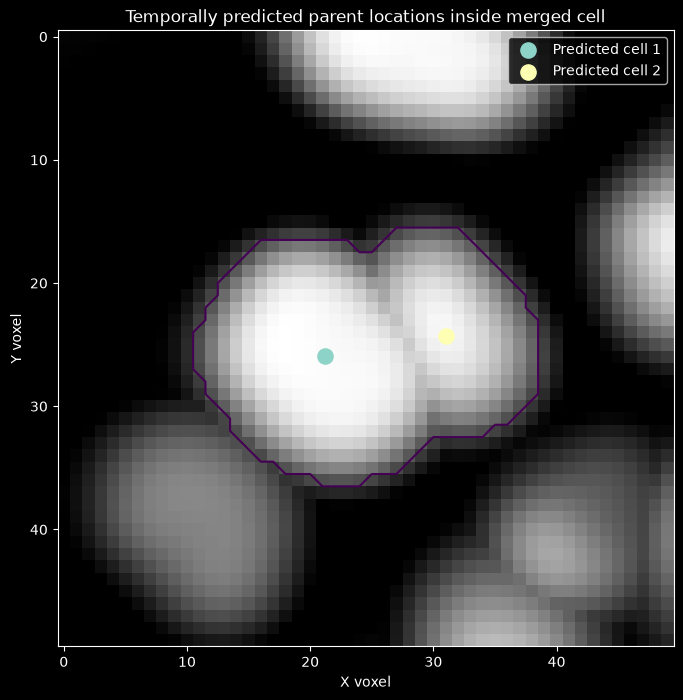

In [307]:
merged_preprocessed_mip = (
    merged_preprocessed.max(axis=0)
)

merged_mask_mip = (
    merged_mask.max(axis=0)
)

plt.figure(figsize=(8, 8))

plt.imshow(
    merged_preprocessed_mip,
    cmap="gray",
)

plt.contour(
    merged_mask_mip.astype(float),
    levels=[0.5],
)

plt.scatter(
    predicted_cell_1_center[2],
    predicted_cell_1_center[1],
    s=120,
    label="Predicted cell 1",
)

plt.scatter(
    predicted_cell_2_center[2],
    predicted_cell_2_center[1],
    s=120,
    label="Predicted cell 2",
)

plt.title(
    "Temporally predicted parent locations "
    "inside merged cell"
)

plt.xlabel("X voxel")
plt.ylabel("Y voxel")
plt.legend()
plt.show()

In [308]:
import napari
import numpy as np

viewer = napari.Viewer(ndisplay=3)

viewer.add_image(
    merged_preprocessed,
    name="Merged preprocessed",
    scale=VOXEL_SIZE_ZYX,
)

viewer.add_labels(
    merged_mask.astype(np.uint8),
    name="Merged mask",
    scale=VOXEL_SIZE_ZYX,
    opacity=0.35,
)

predicted_centers_zyx = np.asarray(
    [
        predicted_cell_1_center,
        predicted_cell_2_center,
    ],
    dtype=float,
)

viewer.add_points(
    predicted_centers_zyx,
    name="Predicted centers",
    scale=VOXEL_SIZE_ZYX,
    size=3,
    face_color=["red", "cyan"],
    ndim=3,
)

napari.run()